In [28]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## DAPHNIE 2024 vs HSE 2017–2018: Covariate Imbalance

### Rationale

Notebook 02 compared each DAPHNIE wave against two HSE targets in a 2×2 design.
This notebook performs the single comparison that directly feeds into the norm
derivation pipeline (notebook 04):

- **Source:** DAPHNIE 2024 only. DAPHNIE 2023 is excluded — it was a pilot study with
  anomalous employment composition (76.9% employed, 4.8% retired), very low ESS after
  reweighting (~42%), and missing `skin`.
- **Target:** HSE 2017–2018 pooled (n ≈ 16,173). HSE 2019 is excluded because it has
  no EQ-5D-5L outcome data; HSE 2022 has no EQ-5D data either. Notebook 011 confirmed
  that HSE 2017 and 2018 are internally consistent on this predictor set.
- **Predictor set:** 17 variables (the notebook 04 set: 13 confirmed predictors +
  `resp` + `skin` + `paVig` + `paMod`, all 0% missing in HSE 2017–18 and DAPHNIE 2024).
  `paVig` and `paMod` are ordinal-encoded: `'<2'` → 1, `'1-2 days'` → 2, `'3+ days'` → 3.

SMD is computed as (DAPHNIE 2024 − HSE 2017–2018); positive values indicate higher
prevalence or mean in DAPHNIE 2024. Survey weights are used for both datasets
(`svy_wt` for DAPHNIE, `wt_int` for HSE).

In [19]:
df = pd.read_csv(DATA_PATH / "wrangled_data.csv", low_memory=False)

hse_1718  = df[df["dataset"].isin(["HSE 2017", "HSE 2018"])].copy()
hse_2022 = df[df["dataset"] == "HSE 2022"].copy()
daphnie24 = df[df["dataset"] == "DAPHNIE 2024"].copy()

print(f"HSE 2017–2018 (pooled): n = {len(hse_1718):,}")
print(f"HSE 2022:               n = {len(hse_2022):,}")
print(f"DAPHNIE 2024:           n = {len(daphnie24):,}")

HSE 2017–2018 (pooled): n = 16,173
HSE 2022:               n = 7,727
DAPHNIE 2024:           n = 5,237


In [20]:
# 17-variable predictor set for notebook 04
# 13 from notebook 03 (confirmed by PI) + resp + skin + paVig + paMod
FEATURES = [
    "Sex", "age7cat",
    "eth2cat", "alcohol_yr",
    "emp_cat_Employed", "emp_cat_Other (Sick/Home/etc)", "emp_cat_Retired",
    "emp_cat_Student", "emp_cat_Unemployed",
    "edu_cat_2",
    "paVig", "paMod",
    "smoke_ecig", "diabetes",
    "meds_num", "ill_dis",
    "resp", "skin",
]

BASE_FEATURES = [
    "Sex", "age7cat",
    "eth2cat", "edu_cat_2",
    "emp_cat_Employed", "emp_cat_Other (Sick/Home/etc)", "emp_cat_Retired",
    "emp_cat_Student", "emp_cat_Unemployed",
    "smoke_ecig", "diabetes",
    "meds_num", "ill_dis"
]
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Features ({len(FEATURES)}): {FEATURES}")

Features (18): ['Sex', 'age7cat', 'eth2cat', 'alcohol_yr', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed', 'edu_cat_2', 'paVig', 'paMod', 'smoke_ecig', 'diabetes', 'meds_num', 'ill_dis', 'resp', 'skin']


In [21]:
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    s, w = series[mask], weights[mask]
    return np.average(s, weights=w)


def weighted_var(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() < 2:
        return np.nan
    s, w = series[mask], weights[mask]
    mu = np.average(s, weights=w)
    return np.average((s - mu) ** 2, weights=w)


def compute_smd(source_series, source_weights, target_series, target_weights):
    """SMD = (source_mean - target_mean) / pooled SD."""
    mu_s = weighted_mean(source_series, source_weights)
    mu_t = weighted_mean(target_series, target_weights)
    if np.isnan(mu_s) or np.isnan(mu_t):
        return np.nan
    var_s = weighted_var(source_series, source_weights)
    var_t = weighted_var(target_series, target_weights)
    if np.isnan(var_s) or np.isnan(var_t):
        return np.nan
    pooled_sd = np.sqrt((var_s + var_t) / 2)
    if pooled_sd == 0:
        return np.nan
    return (mu_s - mu_t) / pooled_sd

In [30]:
src_wt = daphnie24["svy_wt"].fillna(1.0)
tgt_wt_1 = hse_1718["wt_int"].fillna(1.0)
tgt_wt_2 = hse_2022["wt_int"].fillna(1.0)

smds_daph_hse1718 = {
    col: compute_smd(daphnie24[col], src_wt, hse_1718[col], tgt_wt_1)
    for col in FEATURES
}

smd_daph_hse1718_series = (
    pd.Series(smds_daph_hse1718, name="SMD (DAPHNIE 2024 − HSE 2017–18)")
    .sort_values(key=abs, ascending=False)
)

# Weighted means side by side
means = pd.DataFrame({
    "DAPHNIE 2024": {col: weighted_mean(daphnie24[col], src_wt) for col in FEATURES},
    "HSE 2017–18":  {col: weighted_mean(hse_1718[col],  tgt_wt_1) for col in FEATURES},
    "SMD":          smds_daph_hse1718,
}).loc[smd_daph_hse1718_series.index].round(3)
means["Imbalanced"] = means["SMD"].abs().gt(0.1).map({True: "***", False: ""})

print("Weighted means and SMD (DAPHNIE 2024 − HSE 2017–18):")
display(means)

Weighted means and SMD (DAPHNIE 2024 − HSE 2017–18):


,DAPHNIE 2024,HSE 2017–18,SMD,Imbalanced
alcohol_yr,1.599,2.598,-0.878,***
paVig,1.890,1.558,0.410,***
edu_cat_2,0.417,0.292,0.264,***
emp_cat_Unemployed,0.078,0.028,0.225,***
eth2cat,0.216,0.146,0.181,***
paMod,2.248,2.445,-0.175,***
ill_dis,0.351,0.425,-0.152,***
skin,0.031,0.016,0.097,
emp_cat_Employed,0.530,0.569,-0.079,
smoke_ecig,0.224,0.193,0.075,


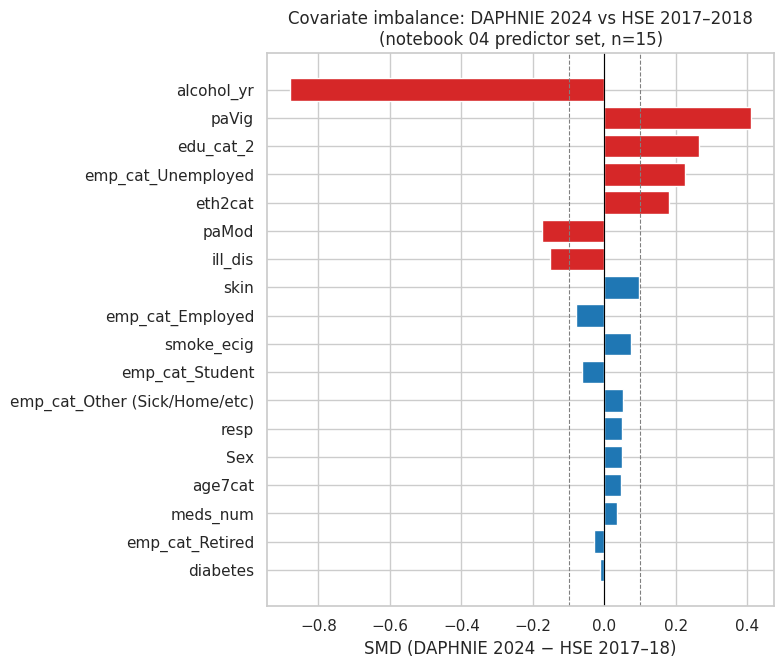

In [31]:
smds_daph_hse1718_plot = smd_daph_hse1718_series.dropna().sort_values(key=abs)
colors = ["#d62728" if abs(v) > 0.1 else "#1f77b4" for v in smds_daph_hse1718_plot]

fig, ax = plt.subplots(figsize=(8, max(5, len(smds_daph_hse1718_plot) * 0.38)))
ax.barh(smds_daph_hse1718_plot.index, smds_daph_hse1718_plot.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("SMD (DAPHNIE 2024 − HSE 2017–18)")
ax.set_title("Covariate imbalance: DAPHNIE 2024 vs HSE 2017–2018\n(notebook 04 predictor set, n=15)")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "love_plot_daphnie24_vs_hse1718.png", dpi=600, bbox_inches="tight")
plt.show()

In [24]:
imbalanced = smd_series[smd_series.abs() > 0.1].sort_values(key=abs, ascending=False)

print(f"Variables with |SMD| > 0.1: {len(imbalanced)} / {len(smd_series.dropna())}")
print()
if len(imbalanced) > 0:
    print("These variables require correction by the density ratio weights in notebook 04:")
    display(imbalanced.round(3).to_frame())

Variables with |SMD| > 0.1: 0 / 0



## Data imbalance with a smaller set of variables

Now we perform the analysis with the baseline features to have a tidier picture.

In [25]:
smds = {
    col: compute_smd(daphnie24[col], src_wt, hse_1718[col], tgt_wt_1)
    for col in BASE_FEATURES
}

smd_series = (
    pd.Series(smds, name="SMD (DAPHNIE 2024 − HSE 2017–18)")
    .sort_values(key=abs, ascending=False)
)

# Weighted means side by side
means = pd.DataFrame({
    "DAPHNIE 2024": {col: weighted_mean(daphnie24[col], src_wt) for col in BASE_FEATURES},
    "HSE 2017–18":  {col: weighted_mean(hse_1718[col],  tgt_wt_1) for col in BASE_FEATURES},
    "SMD":          smds,
}).loc[smd_series.index].round(3)
means["Imbalanced"] = means["SMD"].abs().gt(0.1).map({True: "***", False: ""})

print("Weighted means and SMD (DAPHNIE 2024 − HSE 2017–18):")
display(means)

Weighted means and SMD (DAPHNIE 2024 − HSE 2017–18):


,DAPHNIE 2024,HSE 2017–18,SMD,Imbalanced
edu_cat_2,0.417,0.292,0.264,***
emp_cat_Unemployed,0.078,0.028,0.225,***
eth2cat,0.216,0.146,0.181,***
ill_dis,0.351,0.425,-0.152,***
emp_cat_Employed,0.530,0.569,-0.079,
smoke_ecig,0.224,0.193,0.075,
emp_cat_Student,0.057,0.072,-0.062,
emp_cat_Other (Sick/Home/etc),0.124,0.108,0.051,
Sex,0.534,0.510,0.049,
age7cat,3.870,3.788,0.046,


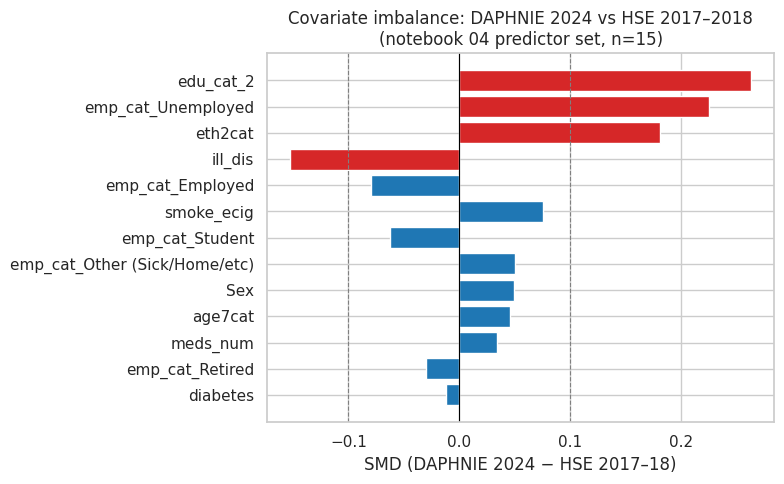

In [26]:
smds_plot = smd_series.dropna().sort_values(key=abs)
colors = ["#d62728" if abs(v) > 0.1 else "#1f77b4" for v in smds_plot]

fig, ax = plt.subplots(figsize=(8, max(5, len(smds_plot) * 0.38)))
ax.barh(smds_plot.index, smds_plot.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("SMD (DAPHNIE 2024 − HSE 2017–18)")
ax.set_title("Covariate imbalance: DAPHNIE 2024 vs HSE 2017–2018\n(notebook 04 predictor set, n=15)")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "love_plot_daphnie24_vs_hse1718_base_features.png", dpi=600, bbox_inches="tight")
plt.show()

In [35]:
smds_daph_hse22 = {
    col: compute_smd(daphnie24[col], src_wt, hse_2022[col], tgt_wt_2)
    for col in FEATURES
}

smd_daph_hse22_series = (
    pd.Series(smds_daph_hse22, name="SMD (DAPHNIE 2024 − HSE 2022)")
    .sort_values(key=abs, ascending=False)
)

# Weighted means side by side
means = pd.DataFrame({
    "DAPHNIE 2024": {col: weighted_mean(daphnie24[col], src_wt) for col in FEATURES},
    "HSE 2022":  {col: weighted_mean(hse_2022[col],  tgt_wt_2) for col in FEATURES},
    "SMD":          smds_daph_hse22,
}).loc[smd_daph_hse22_series.index].round(3)
means["Imbalanced"] = means["SMD"].abs().gt(0.1).map({True: "***", False: ""})

print("Weighted means and SMD (DAPHNIE 2024 − HSE 2022):")
display(means)

Weighted means and SMD (DAPHNIE 2024 − HSE 2022):


,DAPHNIE 2024,HSE 2022,SMD,Imbalanced
alcohol_yr,1.599,2.128,-0.406,***
paVig,1.890,1.589,0.368,***
paMod,2.248,2.572,-0.292,***
emp_cat_Unemployed,0.078,0.020,0.271,***
eth2cat,0.216,0.158,0.148,***
ill_dis,0.351,0.413,-0.127,***
skin,0.031,0.014,0.117,***
emp_cat_Employed,0.530,0.579,-0.100,
edu_cat_2,0.417,0.370,0.094,
resp,0.091,0.068,0.087,


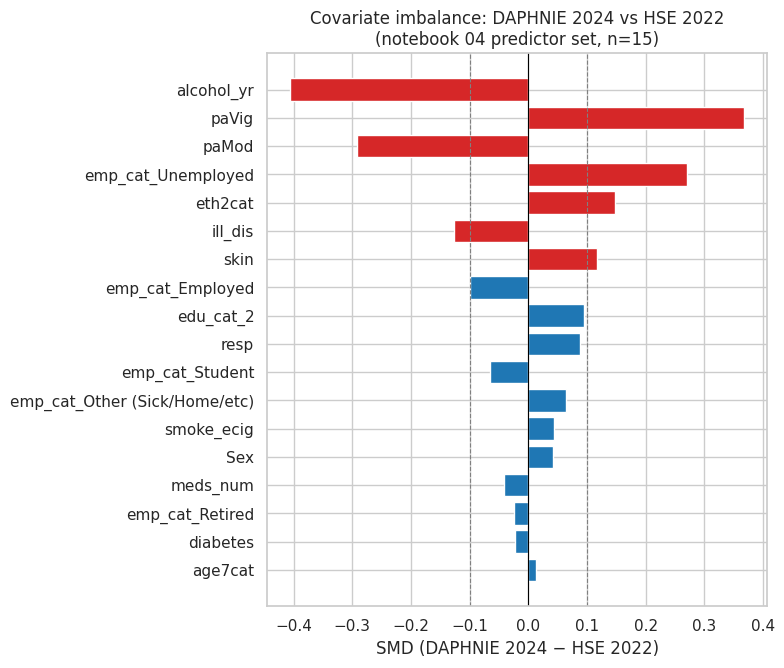

In [36]:
smds_plot = smd_daph_hse22_series.dropna().sort_values(key=abs)
colors = ["#d62728" if abs(v) > 0.1 else "#1f77b4" for v in smds_plot]

fig, ax = plt.subplots(figsize=(8, max(5, len(smds_plot) * 0.38)))
ax.barh(smds_plot.index, smds_plot.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("SMD (DAPHNIE 2024 − HSE 2022)")
ax.set_title("Covariate imbalance: DAPHNIE 2024 vs HSE 2022\n(notebook 04 predictor set, n=15)")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "love_plot_daphnie24_vs_hse2022_base_features.png", dpi=600, bbox_inches="tight")
plt.show()

In [37]:
smds_daph_hse22 = {
    col: compute_smd(daphnie24[col], src_wt, hse_2022[col], tgt_wt_2)
    for col in BASE_FEATURES
}

smd_daph_hse22_series = (
    pd.Series(smds_daph_hse22, name="SMD (DAPHNIE 2024 − HSE 2022)")
    .sort_values(key=abs, ascending=False)
)

# Weighted means side by side
means = pd.DataFrame({
    "DAPHNIE 2024": {col: weighted_mean(daphnie24[col], src_wt) for col in BASE_FEATURES},
    "HSE 2022":  {col: weighted_mean(hse_2022[col],  tgt_wt_2) for col in BASE_FEATURES},
    "SMD":          smds_daph_hse22,
}).loc[smd_daph_hse22_series.index].round(3)
means["Imbalanced"] = means["SMD"].abs().gt(0.1).map({True: "***", False: ""})

print("Weighted means and SMD (DAPHNIE 2024 − HSE 2022):")
display(means)

Weighted means and SMD (DAPHNIE 2024 − HSE 2022):


,DAPHNIE 2024,HSE 2022,SMD,Imbalanced
emp_cat_Unemployed,0.078,0.020,0.271,***
eth2cat,0.216,0.158,0.148,***
ill_dis,0.351,0.413,-0.127,***
emp_cat_Employed,0.530,0.579,-0.100,
edu_cat_2,0.417,0.370,0.094,
emp_cat_Student,0.057,0.073,-0.065,
emp_cat_Other (Sick/Home/etc),0.124,0.104,0.064,
smoke_ecig,0.224,0.206,0.043,
Sex,0.534,0.513,0.043,
meds_num,1.250,1.301,-0.041,


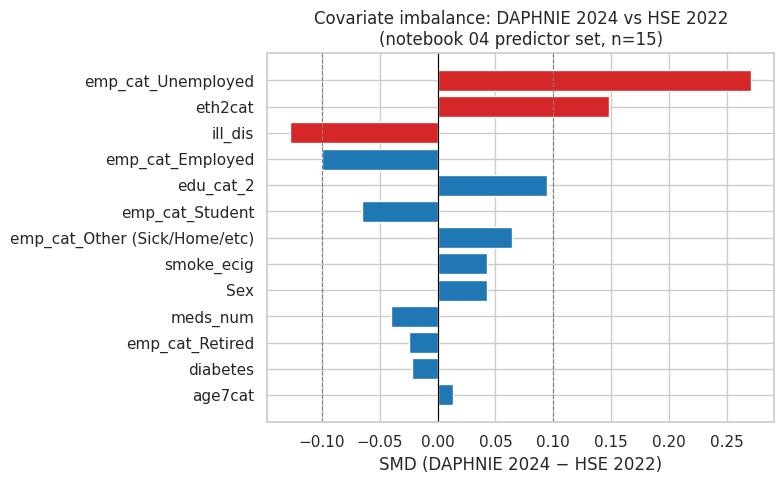

In [38]:
smds_plot = smd_daph_hse22_series.dropna().sort_values(key=abs)
colors = ["#d62728" if abs(v) > 0.1 else "#1f77b4" for v in smds_plot]

fig, ax = plt.subplots(figsize=(8, max(5, len(smds_plot) * 0.38)))
ax.barh(smds_plot.index, smds_plot.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("SMD (DAPHNIE 2024 − HSE 2022)")
ax.set_title("Covariate imbalance: DAPHNIE 2024 vs HSE 2022\n(notebook 04 predictor set, n=15)")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "love_plot_daphnie24_vs_hse2022_base_features.png", dpi=600, bbox_inches="tight")
plt.show()